# Atividade de vendas no Brasil

## Entregável 1 Numpy

In [249]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
df_vendas = pd.read_csv('C:\\Users\\felip\\ufrj-analytica-training\\data\\vendas_brasil_1.csv')

In [250]:
df_vendas

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,22.31,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,30.26,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,21.61,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,41.27,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,9.47,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37612,2023-12-31,3,Porto Alegre,App Mobile,Alimentação,Barra de Cereal,Gabi Alves,Bronze,73.11,47.38,26.52,9,20.3,524.49,8.15,4.95,NaN,False,False,False,False
37613,2023-12-31,9,Salvador,Site Web,Alimentação,Mel Orgânico,Henrique Dias,Bronze,76.62,55.50,22.31,12,10.7,820.52,41.74,4.49,19.0,False,False,False,False
37614,2023-12-31,2,Salvador,Loja Física,Alimentação,Whey Protein,Fábio Ramos,Bronze,55.15,36.94,29.95,7,0.0,384.44,85.35,4.02,14.0,False,True,False,False
37615,2023-12-31,11,São Paulo,Site Web,Esportes,Tapete de Yoga,João Vieira,Bronze,197.09,167.23,10.91,7,10.9,1960.18,30.99,3.50,6.0,False,True,True,False


In [251]:
#A. Criando Arrays
array_custo_unitario = np.array(df_vendas['custo_unitario'])
array_preco_unitario = np.array(df_vendas['preco_unitario'])
array_desconto = np.array(df_vendas['desconto_pct']) 
array_quantidade = np.array(df_vendas['quantidade'])
array_receita_total = np.array(df_vendas['receita_total'])
array_frete = np.array(df_vendas['frete'])

array_custo_unitario, array_preco_unitario, array_desconto, array_quantidade, array_receita_total, array_frete

(array([561.75, 135.15,  61.4 , ...,  36.94, 167.23, 870.69]),
 array([ 739.39,  187.48,   76.11, ...,   55.15,  197.09, 1057.41]),
 array([ 5.2,  0.6,  0.7, ...,  0. , 10.9, 10. ]),
 array([10,  5, 14, ...,  7,  7,  4], dtype=int64),
 array([6933.48,  930.28, 1058.5 , ...,  384.44, 1960.18, 3795.73]),
 array([ 8.68,   nan,  7.98, ..., 85.35, 30.99, 27.23]))

In [252]:
#B. Cálculos com operações vetorizadas
valor_bruto_da_venda = array_preco_unitario * array_quantidade
valor_desconto = valor_bruto_da_venda * array_desconto * 0.01
custo_total = array_custo_unitario * array_quantidade
lucro_estimado = valor_bruto_da_venda - valor_desconto - custo_total

valor_bruto_da_venda, valor_desconto, custo_total, lucro_estimado

(array([7393.9 ,  937.4 , 1065.54, ...,  386.05, 1379.63, 4229.64]),
 array([384.4828 ,   5.6244 ,   7.45878, ...,   0.     , 150.37967,
        422.964  ]),
 array([5617.5 ,  675.75,  859.6 , ...,  258.58, 1170.61, 3482.76]),
 array([1391.9172 ,  256.0256 ,  198.48122, ...,  127.47   ,   58.64033,
         323.916  ]))

In [253]:
#C. Máscaras booleanas
media_receita = np.mean(array_receita_total)
array_receita_acima_da_media = array_receita_total > media_receita
somatorio_receita_acima_da_media = np.sum(array_receita_acima_da_media == True)

array_todos_os_custos = valor_desconto + custo_total
array_vendas_com_prejuizo = array_receita_total < array_todos_os_custos
somatorio_vendas_com_prejuizo = np.sum(array_vendas_com_prejuizo == True)

media_desconto = np.mean(array_desconto)
array_desconto_acima_da_media = array_desconto > media_desconto
somatorio_desconto_acima_da_media = np.sum(array_desconto_acima_da_media == True)

print(f'vendas com receitas acima da média: {somatorio_receita_acima_da_media}')
print(f'vendas com prejuízo: {somatorio_vendas_com_prejuizo}')
print(f'vendas com desconto acima da média: {somatorio_desconto_acima_da_media}')

vendas com receitas acima da média: 9236
vendas com prejuízo: 10266
vendas com desconto acima da média: 17853


In [254]:
#D. Agregações
receita_media = np.mean(array_receita_total)
receita_maxima = np.max(array_receita_total)
receita_minima = np.min(array_receita_total)
lucro_medio = np.mean(lucro_estimado)
vendas_com_prejuizo = np.sum(array_vendas_com_prejuizo == True)


print(f'receita média: {receita_media}')
print(f'receita máxima: {receita_maxima}')
print(f'receita mínima: {receita_minima}')
print(f'lucro médio: {lucro_medio}')
print(f'vendas com prejuízo: {vendas_com_prejuizo}')

receita média: 1891.6881729005502
receita máxima: 58430.28
receita mínima: 3.7
lucro médio: 342.0324771624531
vendas com prejuízo: 10266


## Entregável 2 Pandas

In [255]:
#A. Primeiro olhar no dataset
print('Primeiras 3 linhas do dataset:\n')
df_vendas.head(3)

Primeiras 3 linhas do dataset:



,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,22.31,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,30.26,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,21.61,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False


In [256]:
print('Informações sobre o dataset:\n ')
df_vendas.info()

Informações sobre o dataset:
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34

In [257]:
print('Estatísticas descritivas:\n ')
df_vendas.describe().T

Estatísticas descritivas:
 


,count,mean,std,min,25%,50%,75%,max
mes,37617.0,6.517691,3.439296,1.00,4.00,7.00,9.00,12.00
preco_unitario,37617.0,253.214933,316.742367,4.94,68.96,111.30,257.68,9008.60
custo_unitario,37617.0,183.620999,231.376757,3.01,49.55,80.99,186.57,6578.26
margem_pct,37535.0,22.714776,8.670213,-0.57,16.38,22.70,29.25,44.27
quantidade,37617.0,7.481750,4.322273,1.00,4.00,7.00,11.00,161.00
desconto_pct,37617.0,9.494048,9.097484,0.00,0.30,9.00,19.00,26.00
receita_total,37617.0,1891.688173,2972.445759,3.70,364.28,789.57,1853.21,58430.28
frete,35738.0,29.885737,24.765161,3.75,12.19,22.25,39.48,243.82
avaliacao_cliente,34662.0,3.912094,0.932256,1.00,3.49,4.01,4.52,5.00
prazo_entrega_dias,36113.0,10.017113,5.477487,1.00,5.00,10.00,15.00,19.00


In [258]:
print('Formato do dataset:\n ')
print(df_vendas.shape)
print('\nNúmero de valores ausentes por coluna:')
df_vendas.isna().sum()

Formato do dataset:
 
(37617, 21)

Número de valores ausentes por coluna:


data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

In [259]:
df_vendas.select_dtypes(include=['Int64', 'float64']).columns

Index(['mes', 'preco_unitario', 'custo_unitario', 'margem_pct', 'quantidade',
       'desconto_pct', 'receita_total', 'frete', 'avaliacao_cliente',
       'prazo_entrega_dias'],
      dtype='object')

In [260]:
df_vendas.select_dtypes(exclude=['Int64', 'float64']).columns

Index(['data_venda', 'cidade', 'canal_venda', 'categoria', 'produto',
       'vendedor', 'fidelidade_cliente', 'devolucao', 'entrega_no_prazo',
       'alta_temporada', 'flag_outlier_preco'],
      dtype='object')

### Respostas:

1. Existem 37617 linhas e 21 colunas
2. Sim, existem dados faltantes. Com a maior parte sendo em avaliações dos clientes
3. 'mes', 'preco_unitario', 'custo_unitario', 'margem_pct', 'quantidade', 'desconto_pct', 'receita_total', 'frete', 'avaliacao_cliente', 'prazo_entrega_dias'
4. 'data_venda', 'cidade', 'canal_venda', 'categoria', 'produto',
       'vendedor', 'fidelidade_cliente', 'devolucao', 'entrega_no_prazo',
       'alta_temporada', 'flag_outlier_preco'

In [261]:
#B. Limpeza e tratamento

df_vendas['data_venda'] = pd.to_datetime(df_vendas['data_venda'], format='mixed')

In [262]:
cidades_unico = df_vendas['cidade'].unique().tolist()
cidades_ordenadas = sorted(cidades_unico)
cidades_ordenadas


[' Belo Horizonte',
 ' Curitiba',
 ' Fortaleza',
 ' Goiânia',
 ' Manaus',
 ' Porto Alegre',
 ' Recife',
 ' Rio de Janeiro',
 ' Salvador',
 ' São Paulo',
 'B. Horizonte',
 'BH',
 'Belo Horizonte',
 'Belo Horizonte ',
 'Belo horizonte',
 'Curitiba',
 'Curitiba ',
 'Curtiba',
 'Fortaleza',
 'Fortaleza ',
 'Goiânia',
 'Goiânia ',
 'Manaus',
 'Manaus ',
 'Porto Alegre',
 'Porto Alegre ',
 'RJ',
 'Recife',
 'Recife ',
 'Rio',
 'Rio De Janeiro',
 'Rio de Janeiro',
 'Rio de Janeiro ',
 'Rio de janeiro',
 'S. Paulo',
 'SP',
 'Salvador',
 'Salvador ',
 'Sao Paulo',
 'Slavador',
 'São Paulo',
 'São Paulo ',
 'São paulo',
 'curitiba',
 'salvador']

In [263]:
dicionario_correcao ={
    ' Belo Horizonte': 'Belo Horizonte',
    'B. Horizonte': 'Belo Horizonte',
    'BH': 'Belo Horizonte',
    'Belo Horizonte ': 'Belo Horizonte',
    'Belo horizonte': 'Belo Horizonte',
    ' Curitiba': 'Curitiba',
    'Curitiba ': 'Curitiba',
    'Curtiba': 'Curitiba',
    'curitiba': 'Curitiba',
    ' Fortaleza': 'Fortaleza',
    'Fortaleza ': 'Fortaleza',
    ' Goiânia': 'Goiânia',
    'Goiânia ': 'Goiânia',
    ' Manaus': 'Manaus',
    'Manaus ': 'Manaus',
    ' Porto Alegre': 'Porto Alegre',
    'Porto Alegre ': 'Porto Alegre',
     ' Recife': 'Recife',
    'Recife ': 'Recife',
    ' Rio de Janeiro': 'Rio de Janeiro',
    'Rio de Janeiro ': 'Rio de Janeiro',
    'RJ': 'Rio de Janeiro',
    'Rio': 'Rio de Janeiro',
    'Rio De Janeiro': 'Rio de Janeiro',
    'Rio de janeiro': 'Rio de Janeiro',
    ' São Paulo': 'São Paulo',
    'São Paulo ': 'São Paulo',
    'São paulo': 'São Paulo',
    'SP': 'São Paulo',
    'S. Paulo': 'São Paulo',
    'Sao Paulo': 'São Paulo',
    'Salavador': 'Salvador',
    ' Salvador': 'Salvador',
    'Salvador ': 'Salvador',
    'Slavador': 'Salavador',
    'salvador': 'Salvador',
}

df_vendas['cidade'] = df_vendas['cidade'].replace(dicionario_correcao)

In [264]:
cidades_unico = df_vendas['cidade'].unique().tolist()
cidades_ordenadas = sorted(cidades_unico)
cidades_ordenadas

['Belo Horizonte',
 'Curitiba',
 'Fortaleza',
 'Goiânia',
 'Manaus',
 'Porto Alegre',
 'Recife',
 'Rio de Janeiro',
 'Salavador',
 'Salvador',
 'São Paulo']

In [265]:
df_vendas.fillna({
					"frete": df_vendas["frete"].median()},
					inplace = True
)

Escolhi a mediana para preencher os valores faltantes de frete, pois ela não é afetada por valores discrepantes, diferente da média.

In [266]:
#C. Criação de Novas Colunas
df_vendas['ano'] = df_vendas['data_venda'].dt.year
df_vendas['mes'] = df_vendas['data_venda'].dt.month
df_vendas['receita_liquida'] = df_vendas['preco_unitario'] * df_vendas['quantidade'] - (df_vendas['preco_unitario'] * df_vendas['quantidade'] * df_vendas['desconto_pct'] * 0.01)
df_vendas['lucro_total'] = df_vendas['receita_liquida'] - (df_vendas['custo_unitario'] * df_vendas['quantidade'])
df_vendas['faixas_de_receita'] = df_vendas['receita_liquida'].apply(lambda x: 'Baixa' if x < 500 else 'Média' if x < 1500 else 'Alta')

In [267]:
df_vendas['faixas_de_receita'].value_counts(normalize=True)

faixas_de_receita
Baixa    0.365101
Média    0.360050
Alta     0.274849
Name: proportion, dtype: float64

In [268]:
#D. Filtros

df_vendas[df_vendas['receita_liquida'] > 1000]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,receita_liquida,lucro_total,faixas_de_receita
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,22.31,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False,2022,7009.41720,1391.91720,Alta
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,21.61,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False,2022,1058.08122,198.48122,Média
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,41.27,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False,2022,1594.83324,621.00324,Alta
10,2022-08-03,8,Porto Alegre,Marketplace,Vestuário,Jaqueta,Henrique Dias,Bronze,131.40,104.65,13.65,13,10.7,1533.08,11.85,3.97,7.0,False,True,False,False,2022,1525.42260,164.97260,Alta
11,2022-11-27,11,São Paulo,Site Web,Esportes,Raquete,João Vieira,Prata,130.74,101.92,21.21,12,0.7,2167.48,6.80,4.52,14.0,False,False,True,False,2022,1557.89784,334.85784,Alta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37602,2023-12-31,12,São Paulo,App Mobile,Vestuário,Camiseta,Diego Ferreira,Bronze,102.14,73.00,29.01,13,0.0,1349.92,48.33,NaN,8.0,False,True,False,False,2023,1327.82000,378.82000,Média
37603,2023-12-31,12,Rio de Janeiro,App Mobile,Eletrônicos,Tablet,Inês Nunes,Prata,963.50,608.11,34.11,5,5.4,4554.52,18.19,3.49,3.0,False,True,False,True,2023,4557.35500,1516.80500,Alta
37605,2023-12-31,12,Fortaleza,Marketplace,Esportes,Tapete de Yoga,Carla Mendes,Bronze,352.25,256.20,25.15,10,4.7,3369.62,42.94,3.52,7.0,False,True,False,False,2023,3356.94250,794.94250,Alta
37615,2023-12-31,12,São Paulo,Site Web,Esportes,Tapete de Yoga,João Vieira,Bronze,197.09,167.23,10.91,7,10.9,1960.18,30.99,3.50,6.0,False,True,True,False,2023,1229.25033,58.64033,Média


14483 instâncias de 37617 tiveram receita acima de 1000.

In [269]:
df_vendas[df_vendas['devolucao'] == True]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,receita_liquida,lucro_total,faixas_de_receita
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,30.26,5,0.6,930.28,22.25,4.98,19.0,True,False,False,False,2023,931.77560,256.02560,Média
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,21.61,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False,2022,1058.08122,198.48122,Média
7,2023-09-07,9,Manaus,App Mobile,Alimentação,Mel Orgânico,Inês Nunes,Prata,35.72,21.62,33.34,6,14.5,181.35,24.98,3.03,18.0,True,False,False,False,2023,183.24360,53.52360,Baixa
18,2023-10-24,10,Manaus,Site Web,Vestuário,Camiseta,Carla Mendes,Prata,65.73,41.26,37.54,4,0.0,264.76,56.61,NaN,16.0,True,True,False,False,2023,262.92000,97.88000,Baixa
21,2023-05-07,5,São Paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,23.41,8,4.3,6847.45,9.89,1.05,18.0,True,True,False,True,2023,6835.50648,1550.86648,Alta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37522,2023-12-31,12,Salvador,Marketplace,Esportes,Bicicleta,Carla Mendes,Bronze,195.87,161.39,17.93,13,0.9,3067.61,6.95,2.95,7.0,True,True,True,False,2023,2523.39321,425.32321,Alta
37525,2023-12-31,12,Curitiba,Loja Física,Esportes,Luva de Box,Ana Lima,Prata,248.42,183.21,15.05,12,24.3,3355.83,8.57,2.04,13.0,True,True,True,False,2023,2256.64728,58.12728,Alta
37533,2023-12-31,12,Belo Horizonte,App Mobile,Alimentação,Granola,Henrique Dias,Prata,48.60,36.51,13.03,5,25.7,179.58,13.15,4.49,14.0,True,True,False,False,2023,180.54900,-2.00100,Baixa
37583,2023-12-31,12,Manaus,Loja Física,Eletrônicos,Smartwatch,Henrique Dias,Bronze,846.16,697.37,13.87,11,10.6,8355.56,14.03,1.00,10.0,True,True,False,True,2023,8321.13744,650.06744,Alta


3532 instâncias de 37617 foram devolvidas

In [270]:
df_vendas[df_vendas['categoria'] == 'Esportes']

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,receita_liquida,lucro_total,faixas_de_receita
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,9.47,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False,2022,107.80560,0.55560,Baixa
11,2022-11-27,11,São Paulo,Site Web,Esportes,Raquete,João Vieira,Prata,130.74,101.92,21.21,12,0.7,2167.48,6.80,4.52,14.0,False,False,True,False,2022,1557.89784,334.85784,Alta
22,2023-02-18,2,Belo Horizonte,App Mobile,Esportes,Garrafa Térmica,Inês Nunes,Bronze,184.86,124.85,32.61,1,0.4,184.75,49.33,5.00,1.0,False,True,False,False,2023,184.12056,59.27056,Baixa
23,2023-01-21,1,Manaus,Site Web,Esportes,Bicicleta,Carla Mendes,Bronze,257.83,207.71,20.47,12,0.0,4291.40,23.27,3.99,13.0,False,True,True,False,2023,3093.96000,601.44000,Alta
26,2022-06-10,6,Fortaleza,Loja Física,Esportes,Luva de Box,Fábio Ramos,Prata,216.08,163.24,18.73,6,5.9,1210.78,6.55,4.00,15.0,False,True,False,False,2022,1219.98768,240.54768,Média
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37605,2023-12-31,12,Fortaleza,Marketplace,Esportes,Tapete de Yoga,Carla Mendes,Bronze,352.25,256.20,25.15,10,4.7,3369.62,42.94,3.52,7.0,False,True,False,False,2023,3356.94250,794.94250,Alta
37608,2023-12-31,12,São Paulo,Loja Física,Esportes,Raquete,Gabi Alves,Prata,311.02,248.38,20.50,3,4.5,885.97,91.64,3.95,8.0,False,True,False,False,2023,891.07230,145.93230,Média
37609,2023-12-31,12,Belo Horizonte,App Mobile,Esportes,Luva de Box,Fábio Ramos,Ouro,385.57,299.42,13.67,3,19.5,932.31,5.88,1.99,3.0,False,True,False,False,2023,931.15155,32.89155,Média
37610,2023-12-31,12,Fortaleza,App Mobile,Esportes,Raquete,Henrique Dias,Bronze,179.68,127.43,24.31,2,10.7,458.34,19.31,4.01,2.0,False,True,True,False,2023,320.90848,66.04848,Baixa


7646 instâncias de 37617 são da categoria 'Esportes"

In [271]:
# D. Agrupamentos

df_vendas.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)

categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64

In [272]:
df_vendas.groupby('canal_venda')['receita_total'].count().sort_values(ascending=False)

canal_venda
Site Web       11267
App Mobile     11168
Loja Física     7445
Marketplace     5604
Televendas      1861
app mobile        33
SiteWeb           31
APP Mobile        29
App mobile        28
Site web          24
site web          24
loja física       22
Loja Fisica       18
Loja fisica       13
Name: receita_total, dtype: int64

In [273]:
df_vendas.groupby('cidade')['receita_total'].sum().sort_values(ascending=False)

cidade
Recife            7662241.79
Manaus            7459161.23
Fortaleza         7242081.82
Goiânia           7178113.69
Porto Alegre      7048428.17
Curitiba          6993175.07
Belo Horizonte    6914747.61
Salvador          6892968.99
Rio de Janeiro    6880176.34
São Paulo         6862852.27
Salavador           25687.02
Name: receita_total, dtype: float64

In [274]:
df_vendas.groupby('canal_venda')['lucro_total'].sum().sort_values(ascending=False)

canal_venda
Site Web       3.842404e+06
App Mobile     3.770432e+06
Loja Física    2.673736e+06
Marketplace    1.866487e+06
Televendas     6.400285e+05
APP Mobile     1.455823e+04
loja física    7.690637e+03
Site web       6.166412e+03
app mobile     5.791263e+03
SiteWeb        5.518475e+03
site web       4.481420e+03
App mobile     4.360175e+03
Loja fisica    3.416455e+03
Loja Fisica    3.175102e+03
Name: lucro_total, dtype: float64

In [275]:
# E. Merge

regioes = pd.DataFrame(
    [
        ['Rio de Janeiro', 'Sudeste'],
        ['São Paulo', 'Sudeste'],
        ['Belo Horizonte', 'Sudeste'],
        ['Salvador', 'Nordeste'],
        ['Recife', 'Nordeste'],
        ['Fortaleza', 'Nordeste'],
        ['Curitiba', 'Sul'],
        ['Porto Alegre', 'Sul'],
        ['Manaus', 'Norte'],
        ['Goiânia', 'Centro-Oeste'] 
    ], columns=['cidade', 'regiao']
)

In [276]:
df_vendas.merge(regioes, on='cidade', how='left')

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,receita_liquida,lucro_total,faixas_de_receita,regiao
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,22.31,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False,2022,7009.41720,1391.91720,Alta,Sudeste
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,30.26,5,0.6,930.28,22.25,4.98,19.0,True,False,False,False,2023,931.77560,256.02560,Média,Norte
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,21.61,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False,2022,1058.08122,198.48122,Média,Centro-Oeste
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,41.27,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False,2022,1594.83324,621.00324,Alta,Nordeste
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,9.47,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False,2022,107.80560,0.55560,Baixa,Sudeste
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37612,2023-12-31,12,Porto Alegre,App Mobile,Alimentação,Barra de Cereal,Gabi Alves,Bronze,73.11,47.38,26.52,9,20.3,524.49,8.15,4.95,NaN,False,False,False,False,2023,524.41803,97.99803,Média,Sul
37613,2023-12-31,12,Salvador,Site Web,Alimentação,Mel Orgânico,Henrique Dias,Bronze,76.62,55.50,22.31,12,10.7,820.52,41.74,4.49,19.0,False,False,False,False,2023,821.05992,155.05992,Média,Nordeste
37614,2023-12-31,12,Salvador,Loja Física,Alimentação,Whey Protein,Fábio Ramos,Bronze,55.15,36.94,29.95,7,0.0,384.44,85.35,4.02,14.0,False,True,False,False,2023,386.05000,127.47000,Baixa,Nordeste
37615,2023-12-31,12,São Paulo,Site Web,Esportes,Tapete de Yoga,João Vieira,Bronze,197.09,167.23,10.91,7,10.9,1960.18,30.99,3.50,6.0,False,True,True,False,2023,1229.25033,58.64033,Média,Sudeste


## Entregável 3 Seaborn

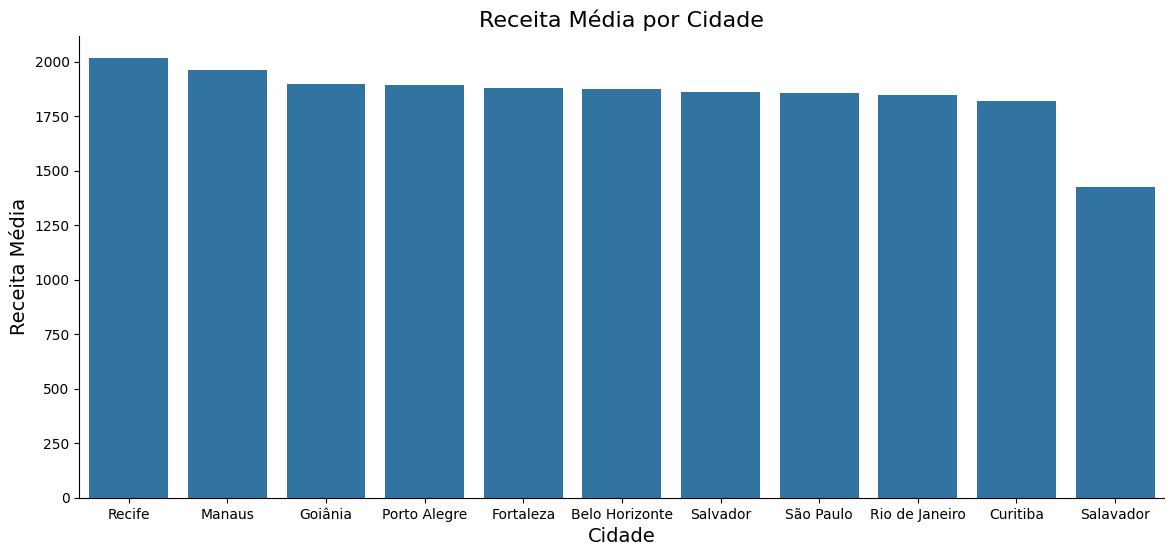

In [282]:
import matplotlib.pyplot as plt
import seaborn as sns


receitamedia_por_cidade = df_vendas.groupby('cidade')['receita_total'].mean().sort_values(ascending=False).reset_index().rename(columns={'receita_total': 'media_receita_total'})

plt.figure(figsize=(14, 6))
sns.barplot(x='cidade', y='media_receita_total', data=receitamedia_por_cidade)
plt.title('Receita Média por Cidade', fontsize=16)
plt.xlabel('Cidade', fontsize=14)
plt.ylabel('Receita Média', fontsize=14)
sns.despine()
plt.show()

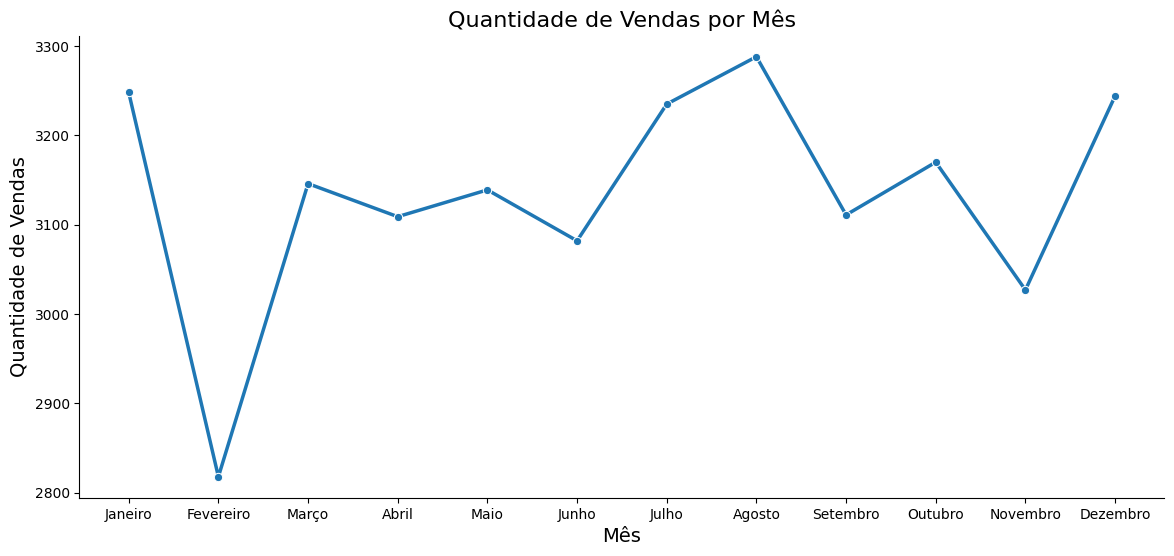

In [290]:
vendas_por_mes = df_vendas.groupby('mes')['receita_total'].count().sort_values(ascending=False).reset_index().rename(columns={'receita_total': 'quantidade_vendas'})
dicionario_meses = {1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho', 7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'}
vendas_por_mes['mes'] = vendas_por_mes['mes'].map(dicionario_meses)
ordenar_meses = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']
vendas_por_mes['mes'] = pd.Categorical(vendas_por_mes['mes'], categories=ordenar_meses, ordered=True)

plt.figure(figsize=(14, 6))
sns.lineplot(x='mes', y='quantidade_vendas', data=vendas_por_mes, marker='o', linewidth=2.5)
plt.title('Quantidade de Vendas por Mês', fontsize=16)
plt.xlabel('Mês', fontsize=14)
plt.ylabel('Quantidade de Vendas', fontsize=14)
plt.xticks(vendas_por_mes['mes'])
sns.despine()
plt.show()

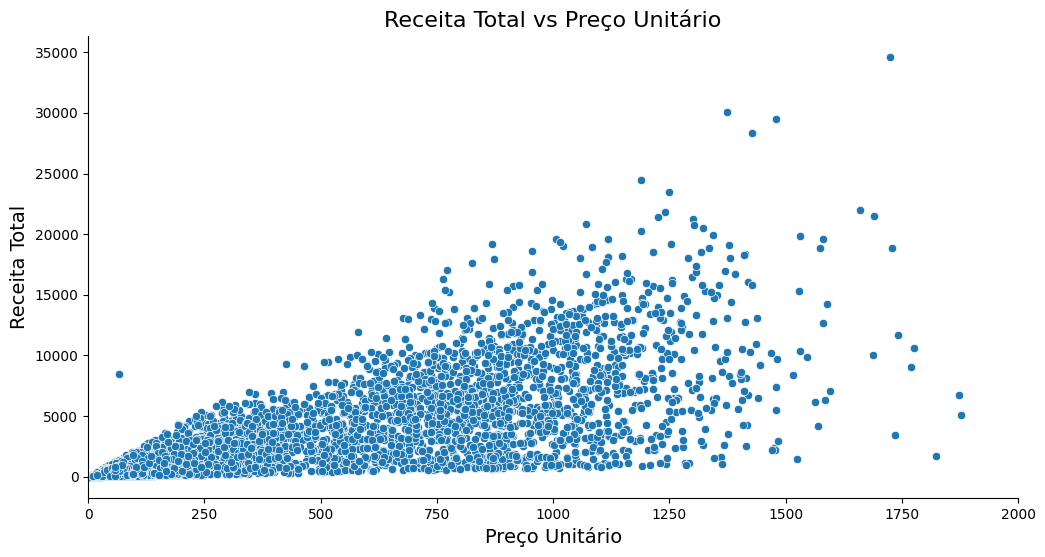

In [327]:
amostra_percentual = df_vendas.sample(frac=0.30)

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(x='preco_unitario', y='receita_total', data=amostra_percentual, ax=ax)
ax.set_title('Receita Total vs Preço Unitário', fontsize=16)
ax.set_xlabel('Preço Unitário', fontsize=14)
ax.set_ylabel('Receita Total', fontsize=14)
ax.set_xlim(0, 2000)
sns.despine()
plt.show()

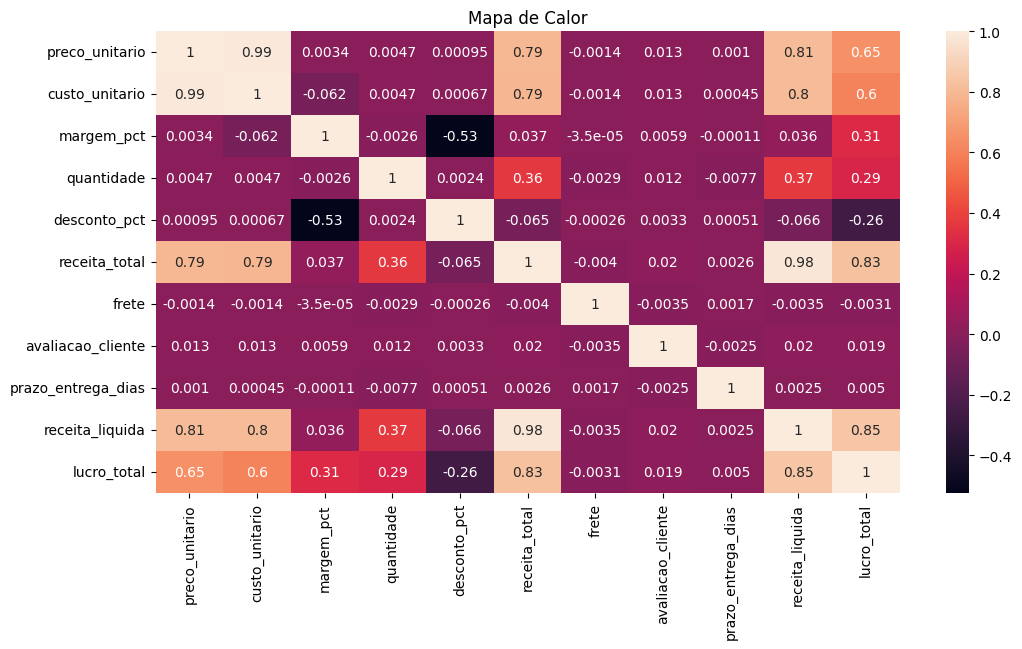

In [321]:
heatmap_data = df_vendas.select_dtypes(include=['Int64', 'float64']).corr()

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True)
plt.title('Mapa de Calor')
plt.show()